In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Engle-Granger Test or Cointegration Test

/var/folders/7l/lswfjppn54zc9mlcflv0453m0000gp/T/ipykernel_9675/317368273.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("financial_data.csv", parse_dates=["Date"], index_col="Date")


        Food CPI  Subsidy_Index  FAO Food Price Index  FAO Meat  \
Date                                                              
Jan-00     -5.34       0.737463                  52.8      60.6   
Feb-00     -2.19       0.737463                  52.5      60.9   
Mar-00      5.86       0.737463                  53.1      62.8   
Apr-00     -1.20       0.737463                  53.7      62.3   
May-00     -0.32       0.737463                  54.0      63.3   

        FAO Dairy Index  FAO Cereals Index  FAO Oils Index  FAO Sugar Index  
Date                                                                         
Jan-00             50.2               52.1           48.58             34.7  
Feb-00             50.4               52.2           46.37             32.7  
Mar-00             50.1               51.7           47.82             31.8  
Apr-00             50.4               51.8           49.50             37.3  
May-00             50.9               52.8           44.49    

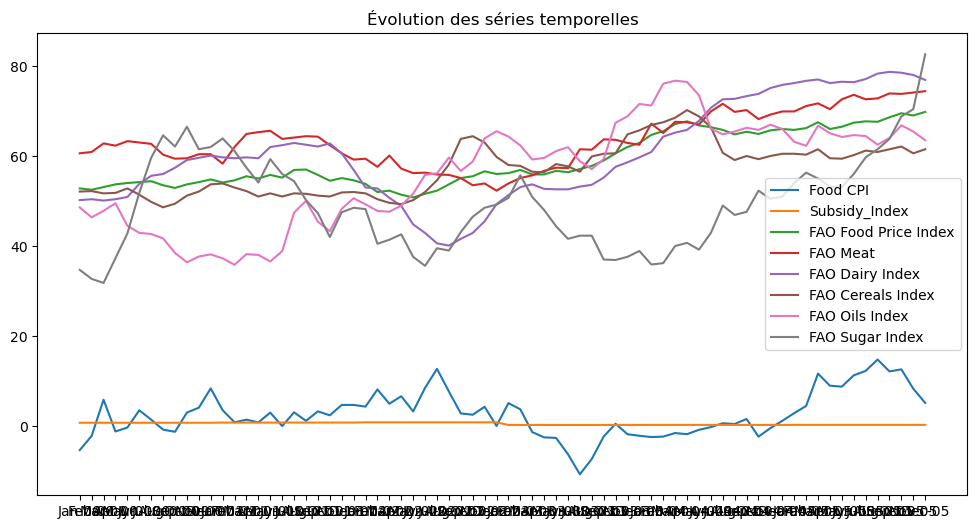

Test de co-intégration entre Food CPI et Subsidy_Index
Statistique: -3.0650, p-value: 0.0956
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Food Price Index
Statistique: -2.9607, p-value: 0.1198
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Meat
Statistique: -3.0470, p-value: 0.0994
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Dairy Index
Statistique: -3.0264, p-value: 0.1041
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Cereals Index
Statistique: -3.0064, p-value: 0.1087
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Oils Index
Statistique: -2.9795, p-value: 0.1152
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Food CPI et FAO Sugar Index
Statistique: -3.1998, p-value: 0.0700
=> Ces séries ne sont pas co-intégrées ❌

Test de co-intégration entre Subsidy_Index e

In [3]:
# === 1. Charger vos données ===
df = pd.read_csv("financial_data.csv", parse_dates=["Date"], index_col="Date")
print(df.head())

# === 2. Visualiser les séries ===
plt.figure(figsize=(12, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.legend()
plt.title("Évolution des séries temporelles")
plt.show()

# === 3. Vérifier la co-intégration par la méthode d'Engle-Granger ===
# Test de co-intégration entre deux séries
def test_coint(series1, series2, alpha=0.05):
    score, p_value, _ = coint(series1, series2)
    print(f"Test de co-intégration entre {series1.name} et {series2.name}")
    print(f"Statistique: {score:.4f}, p-value: {p_value:.4f}")
    if p_value < alpha:
        print("=> Ces séries sont co-intégrées ✅\n")
    else:
        print("=> Ces séries ne sont pas co-intégrées ❌\n")

# Tester toutes les paires de séries
cols = df.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        test_coint(df[cols[i]], df[cols[j]])

# Johansen Test


=== Test de Johansen ===
Valeur propre 1: statistique trace = 204.8561
Valeurs critiques (90%, 95%, 99%): [153.6341 159.529  171.0905]
=> Il y a une co-intégration à 95% ✅

Valeur propre 2: statistique trace = 153.8520
Valeurs critiques (90%, 95%, 99%): [120.3673 125.6185 135.9825]
=> Il y a une co-intégration à 95% ✅

Valeur propre 3: statistique trace = 109.6807
Valeurs critiques (90%, 95%, 99%): [ 91.109   95.7542 104.9637]
=> Il y a une co-intégration à 95% ✅

Valeur propre 4: statistique trace = 75.2749
Valeurs critiques (90%, 95%, 99%): [65.8202 69.8189 77.8202]
=> Il y a une co-intégration à 95% ✅

Valeur propre 5: statistique trace = 43.2586
Valeurs critiques (90%, 95%, 99%): [44.4929 47.8545 54.6815]
=> Pas de co-intégration à 95% ❌

Valeur propre 6: statistique trace = 18.7271
Valeurs critiques (90%, 95%, 99%): [27.0669 29.7961 35.4628]
=> Pas de co-intégration à 95% ❌

Valeur propre 7: statistique trace = 5.5562
Valeurs critiques (90%, 95%, 99%): [13.4294 15.4943 19.9349]
=

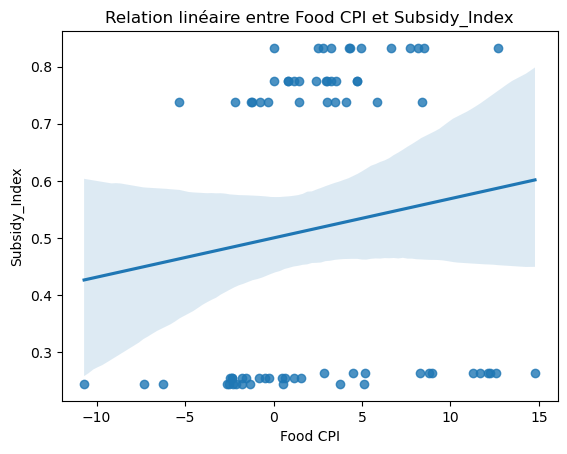

In [4]:

# === 4. Vérifier la co-intégration avec le test de Johansen ===
def johansen_test(data, det_order=0, k_ar_diff=1):
    result = coint_johansen(data, det_order, k_ar_diff)
    trace_stat = result.lr1
    crit_values = result.cvt

    print("\n=== Test de Johansen ===")
    for i in range(len(trace_stat)):
        print(f"Valeur propre {i+1}: statistique trace = {trace_stat[i]:.4f}")
        print(f"Valeurs critiques (90%, 95%, 99%): {crit_values[i]}")
        if trace_stat[i] > crit_values[i, 1]:
            print("=> Il y a une co-intégration à 95% ✅\n")
        else:
            print("=> Pas de co-intégration à 95% ❌\n")

# Appliquer Johansen sur toutes les colonnes
johansen_test(df)

# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[1]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[1]}")
plt.show()


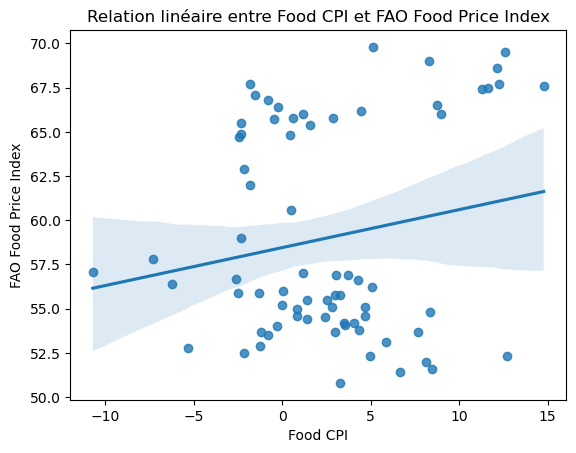

In [5]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[2]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[2]}")
plt.show()


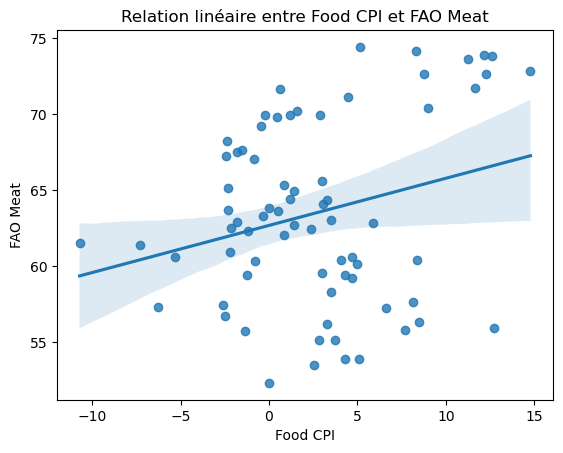

In [6]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[3]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[3]}")
plt.show()

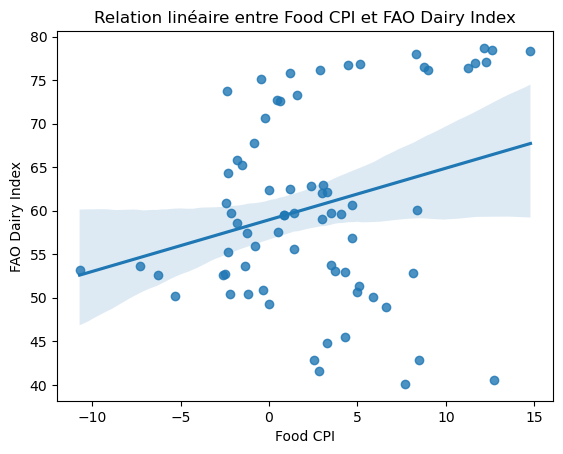

In [7]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[4]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[4]}")
plt.show()

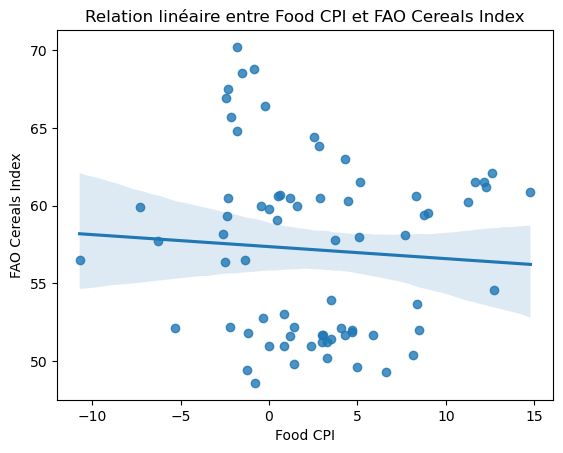

In [8]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[5]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[5]}")
plt.show()

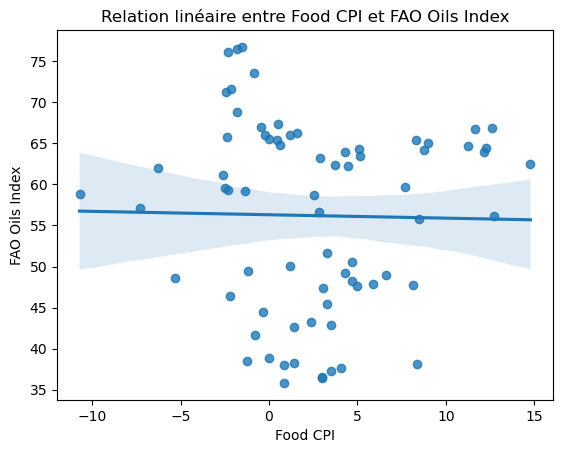

In [9]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[6]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[6]}")
plt.show()

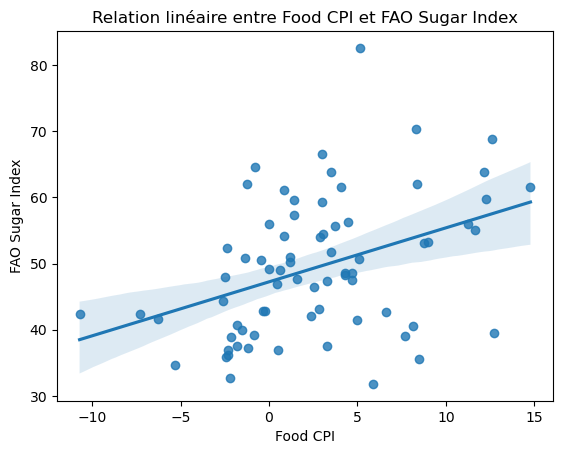

In [10]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[7]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[7]}")
plt.show()

# Cointegrated variables according to Engle-Granger test

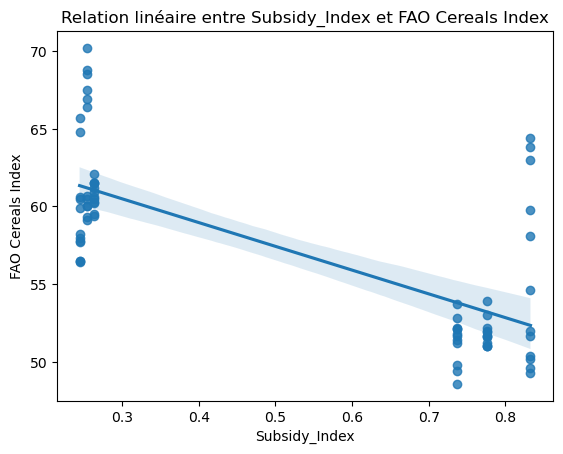

In [17]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[1]], y=df[cols[5]])
plt.title(f"Relation linéaire entre {cols[1]} et {cols[5]}")
plt.show()

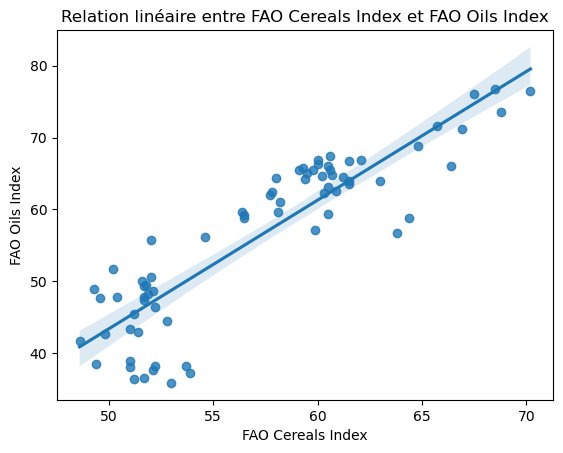

In [18]:
# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[5]], y=df[cols[6]])
plt.title(f"Relation linéaire entre {cols[5]} et {cols[6]}")
plt.show()